In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BACKEND_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from core.model import Autoencoder, FEATURE_ORDER, get_cleaned_train_test_data

print(f"backend dir on path: {BACKEND_DIR}")
print(f"feature order ({len(FEATURE_ORDER)}): {FEATURE_ORDER}")


backend dir on path: D:\ARGUS\backend
feature order (11): ['peak_yaw_delta', 'peak_pitch_delta', 'mean_yaw_delta', 'snap_count', 'min_cv_yaw', 'min_cv_pitch', 'cv_yaw_std', 'cv_pitch_std', 'fire_on_target_rate', 'yaw_jerk', 'engagement_firing_rate']


In [2]:
# Load the cleanlab-cleaned training split (flagged label-issue rows
# removed from TRAIN only, per Phase 1.6/1.6.5) and the untouched test
# split. The autoencoder must only ever see LEGIT training data.
X_train_cleaned, y_train_cleaned, X_test, y_test = get_cleaned_train_test_data()

X_train_legit = X_train_cleaned[y_train_cleaned == 0]

scaler = joblib.load(BACKEND_DIR / "trained_models" / "scaler.pkl")

# Scale legit-only training data with the EXISTING fitted scaler (fit
# on the original uncleaned X_train in notebooks/02) -- never refit here.
X_train_legit_scaled = scaler.transform(X_train_legit)

# Scale the full test set (both classes) for evaluation later.
X_test_scaled = scaler.transform(X_test)

print(f"X_train_cleaned shape: {X_train_cleaned.shape}")
print(f"X_train_legit (label==0 only) shape: {X_train_legit.shape}")
print(f"X_train_legit_scaled shape: {X_train_legit_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"test cheater rate: {y_test.mean():.4f}")


X_train_cleaned shape: (8532, 11)
X_train_legit (label==0 only) shape: (7610, 11)
X_train_legit_scaled shape: (7610, 11)
X_test_scaled shape: (2400, 11)
test cheater rate: 0.1667


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Using device: {device}")


CUDA available: True
Using device: cuda


In [4]:
model = Autoencoder(input_dim=11, hidden_dim=8, bottleneck_dim=5).to(device)
print(model)

# Dummy forward pass sanity check -- fail loudly if shapes don't match.
dummy_input = torch.tensor(X_train_legit_scaled[:1], dtype=torch.float32).to(device)
dummy_output = model(dummy_input)
assert dummy_output.shape == dummy_input.shape, (
    f"shape mismatch: input {dummy_input.shape} vs output {dummy_output.shape}"
)
print(f"Dummy forward pass OK: input shape {dummy_input.shape} == output shape {dummy_output.shape}")


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=5, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=11, bias=True)
  )
)


Dummy forward pass OK: input shape torch.Size([1, 11]) == output shape torch.Size([1, 11])


In [5]:
from sklearn.model_selection import train_test_split as _tts

X_ae_train, X_ae_val = _tts(X_train_legit_scaled, test_size=0.10, random_state=42)

train_tensor = torch.tensor(X_ae_train, dtype=torch.float32)
val_tensor = torch.tensor(X_ae_val, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=128, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS = 200
PATIENCE = 15

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0
stopped_epoch = MAX_EPOCHS

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_train_loss = 0.0
    n_train_samples = 0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch.size(0)
        n_train_samples += batch.size(0)
    epoch_train_loss /= n_train_samples

    model.eval()
    with torch.no_grad():
        val_reconstruction = model(val_tensor)
        epoch_val_loss = criterion(val_reconstruction, val_tensor).item()

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d}: train_loss={epoch_train_loss:.6f} val_loss={epoch_val_loss:.6f}")

    if epochs_without_improvement >= PATIENCE:
        stopped_epoch = epoch
        print(f"Early stopping at epoch {epoch} (no val_loss improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_state)
print(f"Best val_loss: {best_val_loss:.6f}")
print(f"Training ran for {len(train_losses)} epochs (stopped_epoch={stopped_epoch})")


epoch   1: train_loss=0.980259 val_loss=0.941415


epoch  10: train_loss=0.328341 val_loss=0.293233


epoch  20: train_loss=0.217400 val_loss=0.194249


epoch  30: train_loss=0.198784 val_loss=0.179145


epoch  40: train_loss=0.194909 val_loss=0.176704


epoch  50: train_loss=0.194550 val_loss=0.176834


Early stopping at epoch 59 (no val_loss improvement for 15 epochs)
Best val_loss: 0.176135
Training ran for 59 epochs (stopped_epoch=59)


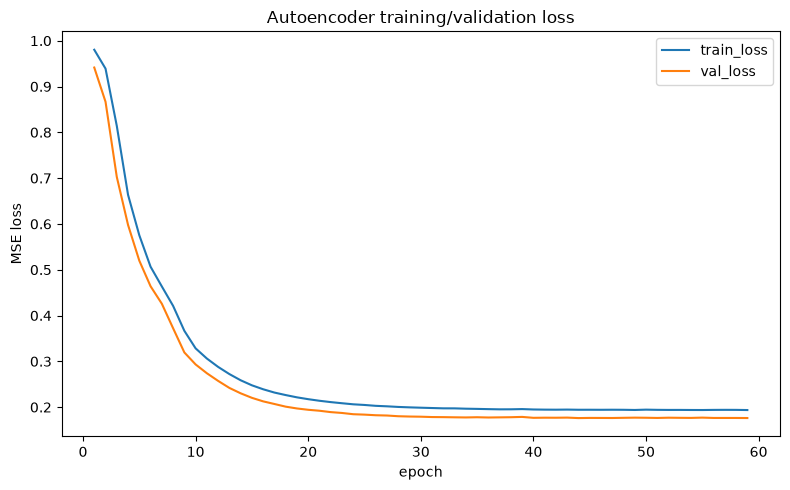

Loss curve saved to D:\ARGUS\backend\notebooks\autoencoder_loss_curve.png
Final train_loss: 0.193678
Final val_loss:   0.176238
Best val_loss:    0.176135
NaN encountered during training: False
No early instability flagged (longest consecutive val_loss increase in first 30 epochs: 0 epochs).


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="train_loss")
ax.plot(range(1, len(val_losses) + 1), val_losses, label="val_loss")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Autoencoder training/validation loss")
ax.legend()
fig.tight_layout()

loss_curve_path = Path("autoencoder_loss_curve.png")
fig.savefig(loss_curve_path, dpi=150)
plt.show()

print(f"Loss curve saved to {loss_curve_path.resolve()}")
print(f"Final train_loss: {train_losses[-1]:.6f}")
print(f"Final val_loss:   {val_losses[-1]:.6f}")
print(f"Best val_loss:    {best_val_loss:.6f}")

any_nan = any(np.isnan(v) for v in train_losses) or any(np.isnan(v) for v in val_losses)
print(f"NaN encountered during training: {any_nan}")

# Flag sustained early instability: val_loss rising for >5 consecutive
# epochs within the first 30 epochs.
early_val = val_losses[:30]
max_consecutive_increase = 0
current_streak = 0
for i in range(1, len(early_val)):
    if early_val[i] > early_val[i - 1]:
        current_streak += 1
        max_consecutive_increase = max(max_consecutive_increase, current_streak)
    else:
        current_streak = 0

if max_consecutive_increase > 5:
    print(f"WARNING: val_loss increased for {max_consecutive_increase} consecutive epochs "
          f"early in training -- possible instability.")
else:
    print(f"No early instability flagged (longest consecutive val_loss increase in first "
          f"30 epochs: {max_consecutive_increase} epochs).")


In [7]:
model.eval()
test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    test_reconstruction = model(test_tensor)
    per_sample_mse = torch.mean((test_reconstruction - test_tensor) ** 2, dim=1).cpu().numpy()

score_min, score_max = per_sample_mse.min(), per_sample_mse.max()
ae_scores_normalized = (per_sample_mse - score_min) / (score_max - score_min)

cheater_scores = ae_scores_normalized[y_test == 1]
legit_scores = ae_scores_normalized[y_test == 0]


def print_score_stats(name, arr):
    print(f"{name} (n={len(arr)}):")
    print(f"  mean={arr.mean():.4f} std={arr.std():.4f} "
          f"p50={np.percentile(arr, 50):.4f} p90={np.percentile(arr, 90):.4f} "
          f"p95={np.percentile(arr, 95):.4f}")


print("Autoencoder reconstruction-error score distribution (0=best reconstructed, 1=worst):")
print_score_stats("cheater", cheater_scores)
print_score_stats("legit", legit_scores)


Autoencoder reconstruction-error score distribution (0=best reconstructed, 1=worst):
cheater (n=400):
  mean=0.0125 std=0.0533 p50=0.0047 p90=0.0186 p95=0.0423
legit (n=2000):
  mean=0.0071 std=0.0200 p50=0.0036 p90=0.0126 p95=0.0192


In [8]:
from sklearn.metrics import precision_recall_curve, roc_auc_score

AUC_ISOLATION_FOREST = 0.5866  # Week 1 legit-only novelty fit (Phase 1.5)
AUC_SUPERVISED_CEILING = 0.6745  # reference only, never deployed (Phase 1.6.5)

auc_autoencoder = roc_auc_score(y_test, ae_scores_normalized)

print(f"Autoencoder AUC-ROC on test set:              {auc_autoencoder:.4f}")
print(f"Isolation Forest AUC-ROC (Week 1 reference):   {AUC_ISOLATION_FOREST:.4f}")
print(f"Supervised diagnostic ceiling (reference only): {AUC_SUPERVISED_CEILING:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_test, ae_scores_normalized)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = int(np.argmax(f1_scores))

print()
print(f"F1-maximizing threshold: {thresholds[best_idx]:.4f}")
print(f"  Precision (cheater class): {precisions[best_idx]:.4f}")
print(f"  Recall    (cheater class): {recalls[best_idx]:.4f}")
print(f"  F1        (cheater class): {f1_scores[best_idx]:.4f}")


Autoencoder AUC-ROC on test set:              0.5643
Isolation Forest AUC-ROC (Week 1 reference):   0.5866
Supervised diagnostic ceiling (reference only): 0.6745

F1-maximizing threshold: 0.0037
  Precision (cheater class): 0.1998
  Recall    (cheater class): 0.6075
  F1        (cheater class): 0.3007


In [9]:
# Isolation Forest scores on the SAME X_test, normalized 0-1 the same
# way as in core.model.train_isolation_forest / notebooks/02 (higher =
# more anomalous), so the two signals sit on a comparable scale for the
# ensemble average.
iso_forest = joblib.load(BACKEND_DIR / "trained_models" / "isolation_forest.pkl")
iso_raw_scores = -iso_forest.decision_function(X_test)
iso_min, iso_max = iso_raw_scores.min(), iso_raw_scores.max()
iso_scores_normalized = (iso_raw_scores - iso_min) / (iso_max - iso_min)

auc_isolation_forest_actual = roc_auc_score(y_test, iso_scores_normalized)

ensemble_scores = 0.5 * iso_scores_normalized + 0.5 * ae_scores_normalized
auc_ensemble = roc_auc_score(y_test, ensemble_scores)

print(f"Isolation Forest AUC-ROC (this run's saved model): {auc_isolation_forest_actual:.4f}")
print(f"Autoencoder AUC-ROC:                                {auc_autoencoder:.4f}")
print(f"Ensemble (50/50 average) AUC-ROC:                   {auc_ensemble:.4f}")

beats_iso = auc_ensemble > auc_isolation_forest_actual
beats_ae = auc_ensemble > auc_autoencoder
if beats_iso and beats_ae:
    print("Ensemble beats BOTH individual models.")
elif beats_iso or beats_ae:
    print(f"Ensemble beats only one individual model "
          f"(beats Isolation Forest: {beats_iso}, beats Autoencoder: {beats_ae}).")
else:
    print("Ensemble does NOT beat either individual model alone.")


Isolation Forest AUC-ROC (this run's saved model): 0.5904
Autoencoder AUC-ROC:                                0.5643
Ensemble (50/50 average) AUC-ROC:                   0.5912
Ensemble beats BOTH individual models.


In [10]:
import json as _json

MODELS_DIR = BACKEND_DIR / "trained_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(best_state, MODELS_DIR / "autoencoder.pt")

config = {
    "input_dim": 11,
    "hidden_dim": 8,
    "bottleneck_dim": 5,
    "feature_order": FEATURE_ORDER,
}
config_path = MODELS_DIR / "autoencoder_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    _json.dump(config, f, indent=2)

print(f"Autoencoder state dict saved to {MODELS_DIR / 'autoencoder.pt'}")
print(f"Autoencoder config saved to {config_path}")
print(_json.dumps(config, indent=2))


Autoencoder state dict saved to D:\ARGUS\backend\trained_models\autoencoder.pt


Autoencoder config saved to D:\ARGUS\backend\trained_models\autoencoder_config.json
{
  "input_dim": 11,
  "hidden_dim": 8,
  "bottleneck_dim": 5,
  "feature_order": [
    "peak_yaw_delta",
    "peak_pitch_delta",
    "mean_yaw_delta",
    "snap_count",
    "min_cv_yaw",
    "min_cv_pitch",
    "cv_yaw_std",
    "cv_pitch_std",
    "fire_on_target_rate",
    "yaw_jerk",
    "engagement_firing_rate"
  ]
}
